# 1. Loading our data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Data/players_data_light-2024_2025.csv')
df.shape

(2854, 165)

In [4]:
df.columns.to_list()

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Comp',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'G+A-PK',
 'xG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'FK',
 'PK_stats_shooting',
 'PKatt_stats_shooting',
 'xG_stats_shooting',
 'npxG_stats_shooting',
 'npxG/Sh',
 'G-xG',
 'np:G-xG',
 'Cmp',
 'Att',
 'Cmp%',
 'TotDist',
 'PrgDist',
 'Ast_stats_passing',
 'xAG_stats_passing',
 'xA',
 'A-xAG',
 'KP',
 '1/3',
 'PPA',
 'CrsPA',
 'PrgP_stats_passing',
 'Live',
 'Dead',
 'FK_stats_passing_types',
 'TB',
 'Sw',
 'Crs',
 'TI',
 'CK',
 'In',
 'Out',
 'Str',
 'Cmp_stats_passing_types',
 'Tkl',
 'TklW',
 'Def 3rd',
 'Mid 3rd',
 'Att 3rd',
 'Att_stats_defense',
 'Tkl%',
 'Lost',
 'Blocks_stats_defense',
 'Sh_stats_defense',
 'Pass',
 'Int',
 'Tkl+Int',
 'Clr',
 'Err',
 'SCA',
 'SCA90',
 'PassLive',
 'PassDead',
 'TO',


In [5]:
# Remove goalkeepers
df_outfield = df[~df['Pos'].str.contains('GK', na=False)].copy()

df_outfield.shape

(2642, 165)

In [6]:
df_outfield['Pos'].value_counts()

Pos
DF       859
MF       589
FW       371
FW,MF    325
MF,FW    230
DF,MF    110
MF,DF     81
DF,FW     53
FW,DF     24
Name: count, dtype: int64

In [7]:
# Filter to players with at least 900 minutes played
# This ensures per-90 stats are based on enough data to be meaningful

df_outfield = df_outfield[df_outfield['Min'] >= 900].copy()

df_outfield.shape

(1450, 165)

In [8]:
print(f"\nMin minutes: {df_outfield['Min'].min()}")
print(f"Max minutes: {df_outfield['Min'].max()}")
print(f"Mean minutes: {df_outfield['Min'].mean():.0f}")


Min minutes: 900
Max minutes: 3420
Mean minutes: 1904


# 2. Feature Selection and Normalization

In [9]:
attacking = ['npxG', 'Sh', 'SoT', 'G/Sh', 'Dist']

creating = ['xAG', 'xA', 'KP', 'PPA', 'CrsPA', 'SCA90']

passing = ['Cmp%', 'PrgDist', 'KP', '1/3', 'TB', 'Sw', 'Crs']

carrying = ['PrgC', 'PrgR', 'Carries', 'Succ', 'Succ%', 'Mis', 'Dis']

defending = ['Tkl', 'TklW', 'Int', 'Blocks_stats_defense', 'Clr', 'Err', 'Recov']

positioning = ['Touches', 'Att 3rd_stats_possession', 
               'Mid 3rd_stats_possession', 'Def 3rd_stats_possession']

# Check they all exist in our dataframe
all_features = attacking + creating + passing + carrying + defending + positioning
missing = [f for f in all_features if f not in df_outfield.columns]
print("Missing columns:", missing)
print("Total candidate features:", len(all_features))

Missing columns: []
Total candidate features: 36


In [10]:
# Final feature set - these describe HOW a player plays, not who they are
features = [
    # Attacking threat
    'npxG',      # Shot quality + volume (non-penalty, removes luck)
    'Sh',        # Raw shot volume
    'Dist',      # Average shot distance - differentiates poachers vs long-range shooters
    
    # Creating chances
    'xA',        # Quality of chances created by passing
    'KP',        # Passes that led directly to a shot
    'PPA',       # Passes into the penalty area
    'CrsPA',     # Crosses into the penalty area
    'SCA90',     # Shot-creating actions per 90
    
    # Passing profile
    'Cmp%',      # Pass completion - risk vs safety
    'PrgDist',   # How far forward passes travel
    '1/3',       # Passes into the final third
    'TB',        # Through balls - risk-taking passer signal
    'Sw',        # Switches of play - wide/deep distributor signal
    
    # Carrying & dribbling
    'PrgC',      # Progressive carries - drives the ball forward
    'Succ%',     # Dribble success rate
    'Mis',       # Miscontrols - proxy for playing under pressure
    'Dis',       # Dispossessed - proxy for playing under pressure
    
    # Defending
    'Tkl',       # Tackles attempted
    'TklW',      # Tackles won
    'Int',       # Interceptions
    'Blocks_stats_defense',  # Blocks
    'Clr',       # Clearances - defender signal
    'Recov',     # Ball recoveries
    
    # Positioning (where on pitch they operate)
    'Att 3rd_stats_possession',  # Touches in attacking third
    'Mid 3rd_stats_possession',  # Touches in middle third
    'Def 3rd_stats_possession',  # Touches in defensive third
    'Touches',                   # Total involvement
]

print(f"Final feature count: {len(features)}")

Final feature count: 27


In [11]:
df_outfield[features].isnull().sum().sort_values(ascending=False)

Succ%                       15
Dist                         4
npxG                         0
Def 3rd_stats_possession     0
Mid 3rd_stats_possession     0
Att 3rd_stats_possession     0
Recov                        0
Clr                          0
Blocks_stats_defense         0
Int                          0
TklW                         0
Tkl                          0
Dis                          0
Mis                          0
PrgC                         0
Sh                           0
Sw                           0
TB                           0
1/3                          0
PrgDist                      0
Cmp%                         0
SCA90                        0
CrsPA                        0
PPA                          0
KP                           0
xA                           0
Touches                      0
dtype: int64

In [12]:
df_outfield['Succ%'] = df_outfield['Succ%'].fillna(0)
df_outfield['Dist'] = df_outfield['Dist'].fillna(0)

# Verify no more nulls
print(df_outfield[features].isnull().sum().sum(), "nulls remaining")

0 nulls remaining


In [13]:
# These are counting stats - they need to be per 90 to remove playing time bias
# Rate stats (%, SCA90) are already per-90 or rate-based - don't divide those
counting_stats = [
    'npxG', 'Sh', 'xA', 'KP', 'PPA', 'CrsPA',
    'PrgDist', '1/3', 'TB', 'Sw', 'PrgC', 'Mis', 'Dis',
    'Tkl', 'TklW', 'Int', 'Blocks_stats_defense', 'Clr', 'Recov',
    'Att 3rd_stats_possession', 'Mid 3rd_stats_possession',
    'Def 3rd_stats_possession', 'Touches'
]



In [14]:
# Divide each counting stat by 90s played
for col in counting_stats:
    df_outfield[col + '_p90'] = df_outfield[col] / df_outfield['90s']



In [15]:
# Rate stats stay as-is - just rename for clarity
rate_stats = ['Cmp%', 'SCA90', 'Succ%', 'Dist']



In [16]:
# Build final feature list using the new p90 column names
features_p90 = [col + '_p90' for col in counting_stats] + rate_stats

print(f"Total features for clustering: {len(features_p90)}")
print(features_p90)

Total features for clustering: 27
['npxG_p90', 'Sh_p90', 'xA_p90', 'KP_p90', 'PPA_p90', 'CrsPA_p90', 'PrgDist_p90', '1/3_p90', 'TB_p90', 'Sw_p90', 'PrgC_p90', 'Mis_p90', 'Dis_p90', 'Tkl_p90', 'TklW_p90', 'Int_p90', 'Blocks_stats_defense_p90', 'Clr_p90', 'Recov_p90', 'Att 3rd_stats_possession_p90', 'Mid 3rd_stats_possession_p90', 'Def 3rd_stats_possession_p90', 'Touches_p90', 'Cmp%', 'SCA90', 'Succ%', 'Dist']


In [17]:
print(f"Total features for clustering: {len(features_p90)}")
print(df_outfield[features_p90].isnull().sum().sum(), "nulls remaining")
print(df_outfield.shape)

Total features for clustering: 27
0 nulls remaining
(1450, 188)


# 3. Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_outfield[features_p90])

print(f"Shape going into clustering: {X_scaled.shape}")
print(f"Mean of first feature (should be ~0): {X_scaled[:, 0].mean():.4f}")
print(f"Std of first feature (should be ~1): {X_scaled[:, 0].std():.4f}")

Shape going into clustering: (1450, 27)
Mean of first feature (should be ~0): -0.0000
Std of first feature (should be ~1): 1.0000


# 4. t-SNE

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,   # Reduce to 2 dimensions so we can visualize
    perplexity=40,    
    random_state=42,  
    max_iter=1000       
)

X_tsne = tsne.fit_transform(X_scaled)
print(f"Shape after t-SNE: {X_tsne.shape}")

Shape after t-SNE: (1450, 2)


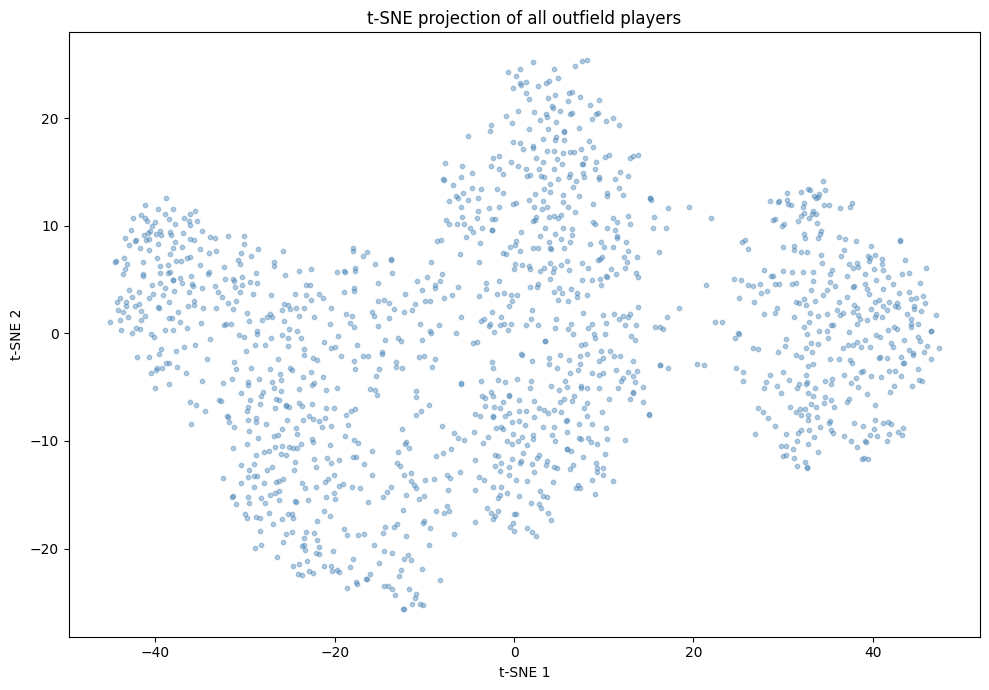

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=10, color='steelblue')
plt.title('t-SNE projection of all outfield players')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

# 5. K-means    

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
inertias = []
silhouette_scores = []
k_range = range(4,16)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tsne)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_tsne,labels))
    print(f"k={k}  silhouette={silhouette_score(X_tsne, labels):.3f}")

k=4  silhouette=0.483
k=5  silhouette=0.486
k=6  silhouette=0.489
k=7  silhouette=0.456
k=8  silhouette=0.396
k=9  silhouette=0.397
k=10  silhouette=0.400
k=11  silhouette=0.412
k=12  silhouette=0.397
k=13  silhouette=0.390
k=14  silhouette=0.387
k=15  silhouette=0.388


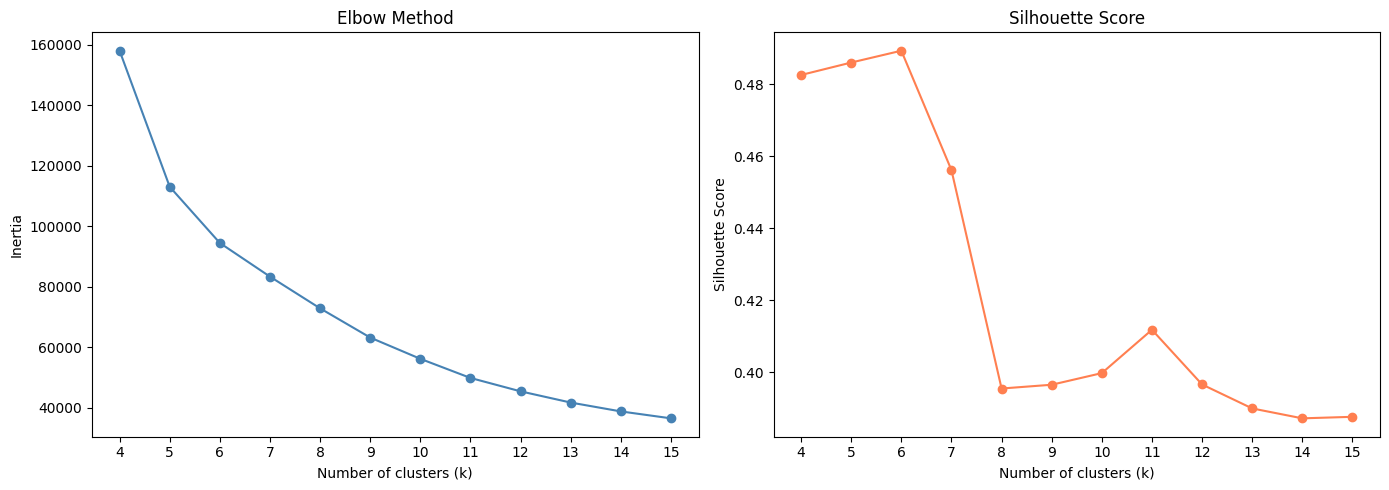

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(k_range, inertias, 'o-', color='steelblue')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.set_xticks(k_range)

# Silhouette plot
ax2.plot(k_range, silhouette_scores, 'o-', color='coral')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

In [28]:
km = KMeans(n_clusters=11, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_tsne)

# Attach labels back to our dataframe
df_outfield['cluster'] = cluster_labels

# how many players in each cluster?
df_outfield['cluster'].value_counts().sort_index()

cluster
0     138
1     105
2     114
3     180
4     164
5     114
6     118
7     130
8     152
9     118
10    117
Name: count, dtype: int64

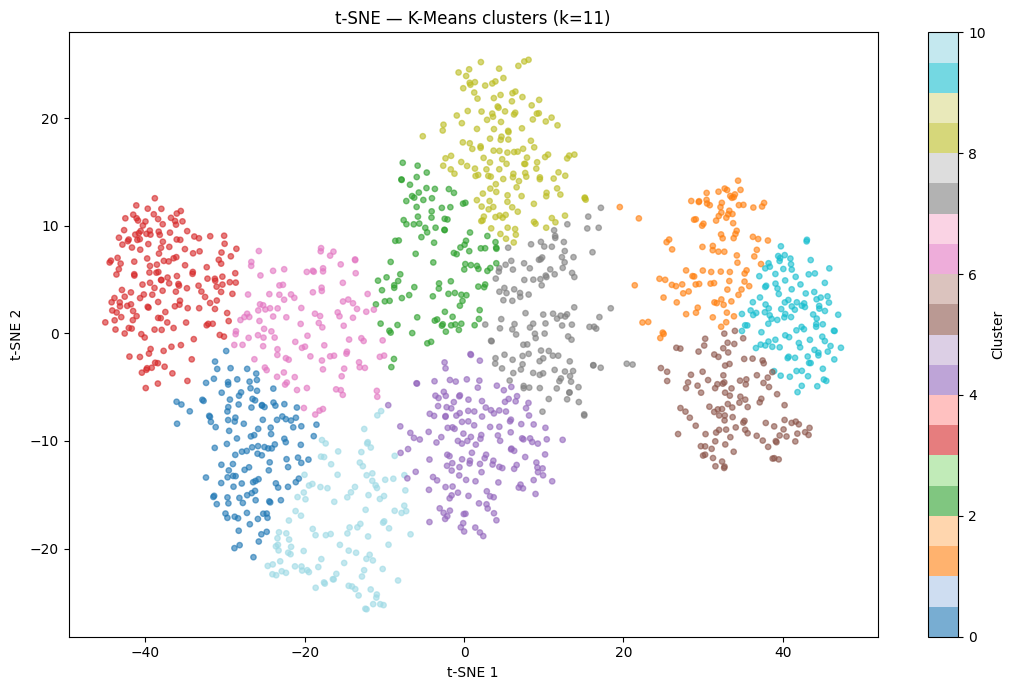

In [29]:
plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=cluster_labels, 
                      cmap='tab20',
                      alpha=0.6, 
                      s=15)
plt.colorbar(scatter, label='Cluster')
plt.title('t-SNE — K-Means clusters (k=11)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

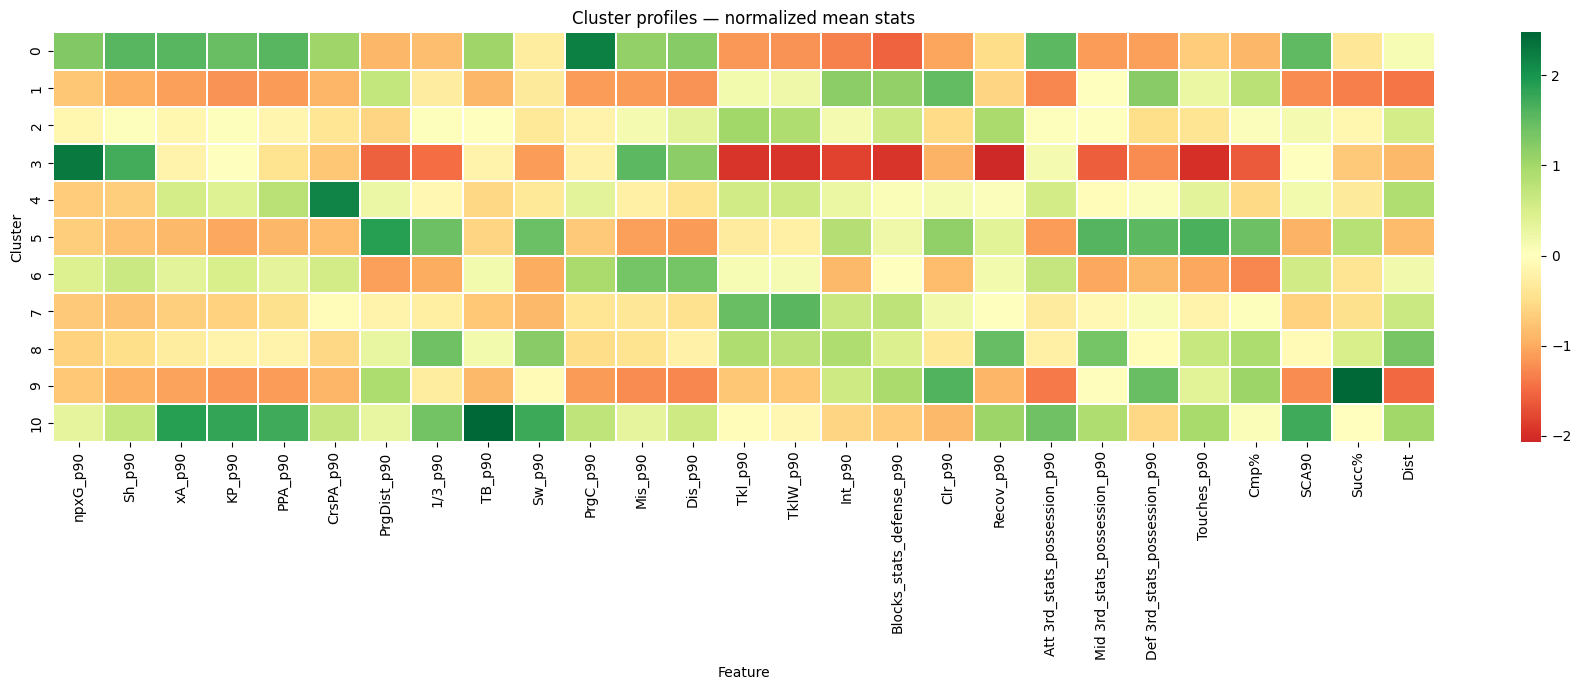

In [30]:
# Get the mean per-90 stats for each cluster
# This tells us what the "average player" in each cluster looks like
cluster_profiles = df_outfield.groupby('cluster')[features_p90].mean()

# Normalize these means so we can compare across features fairly
# (z-score each column so we see "above/below average" for each stat)
cluster_profiles_norm = (cluster_profiles - cluster_profiles.mean()) / cluster_profiles.std()

# Heatmap of all clusters vs all features
plt.figure(figsize=(18, 7))
sns.heatmap(cluster_profiles_norm, 
            cmap='RdYlGn',
            center=0,
            annot=False,
            linewidths=0.3)
plt.title('Cluster profiles — normalized mean stats')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

In [31]:
# Show top 8 players per cluster by minutes played
for i in range(11):
    players = df_outfield[df_outfield['cluster'] == i].nlargest(8, 'Min')[['Player', 'Pos', 'Squad', 'Min']]
    print(f"\n--- Cluster {i} ---")
    print(players.to_string(index=False))


--- Cluster 0 ---
           Player   Pos       Squad  Min
     Bryan Mbeumo    FW   Brentford 3414
    Mohamed Salah    FW   Liverpool 3371
      Cole Palmer MF,FW     Chelsea 3191
Tijjani Reijnders    MF       Milan 3128
    Morgan Rogers FW,MF Aston Villa 3114
   Dodi Lukebakio    FW     Sevilla 3092
       Alex Iwobi FW,MF      Fulham 2981
     Jarrod Bowen FW,MF    West Ham 2973

--- Cluster 1 ---
            Player Pos          Squad  Min
     Obite N'Dicka  DF           Roma 3420
Sebastiano Luperto  DF       Cagliari 3240
  Gianluca Mancini  DF           Roma 3143
         Jay Idzes  DF        Venezia 3127
   Maxence Lacroix  DF Crystal Palace 3116
    Patrick Mainka  DF     Heidenheim 3060
       Enzo Boyomo  DF        Osasuna 2987
     Diego Coppola  DF  Hellas Verona 2927

--- Cluster 2 ---
                    Player   Pos         Squad  Min
            Emmanuel Gyasi DF,FW        Empoli 3217
                Simon Sohm    MF         Parma 2989
                Lewis Cook MF,D

In [36]:
archetype_names = {
    0: 'Dynamic Attacker',
    1: 'Defensive CB',
    2: 'Recycler',       
    3: 'Pure Striker',
    4: 'Attacking Fullback',
    5: 'Ball-Playing CB',
    6: 'Wide Attacker',
    7: 'Defensive Fullback',
    8: 'Box-to-Box Mid',
    9: 'Stopper CB',
    10: 'Playmaker'
}

df_outfield['archetype'] = df_outfield['cluster'].map(archetype_names)
df_outfield['archetype'].value_counts()

archetype
Pure Striker          180
Attacking Fullback    164
Box-to-Box Mid        152
Dynamic Attacker      138
Defensive Fullback    130
Stopper CB            118
Wide Attacker         118
Playmaker             117
Ball-Playing CB       114
Recycler              114
Defensive CB          105
Name: count, dtype: int64

In [37]:
import matplotlib.patches as mpatches

colors = {
    'Dynamic Attacker': '#e63946',
    'Pure Striker': '#f4a261',
    'Wide Attacker': '#e9c46a',
    'Playmaker': '#2a9d8f',
    'Box-to-Box Mid': '#457b9d',
    'Recycler': '#a8dadc',
    'Attacking Fullback': '#6a4c93',
    'Defensive Fullback': '#9b72cf',
    'Ball-Playing CB': '#52b788',
    'Defensive CB': '#95d5b2',
    'Stopper CB': '#b7c4cf',
}


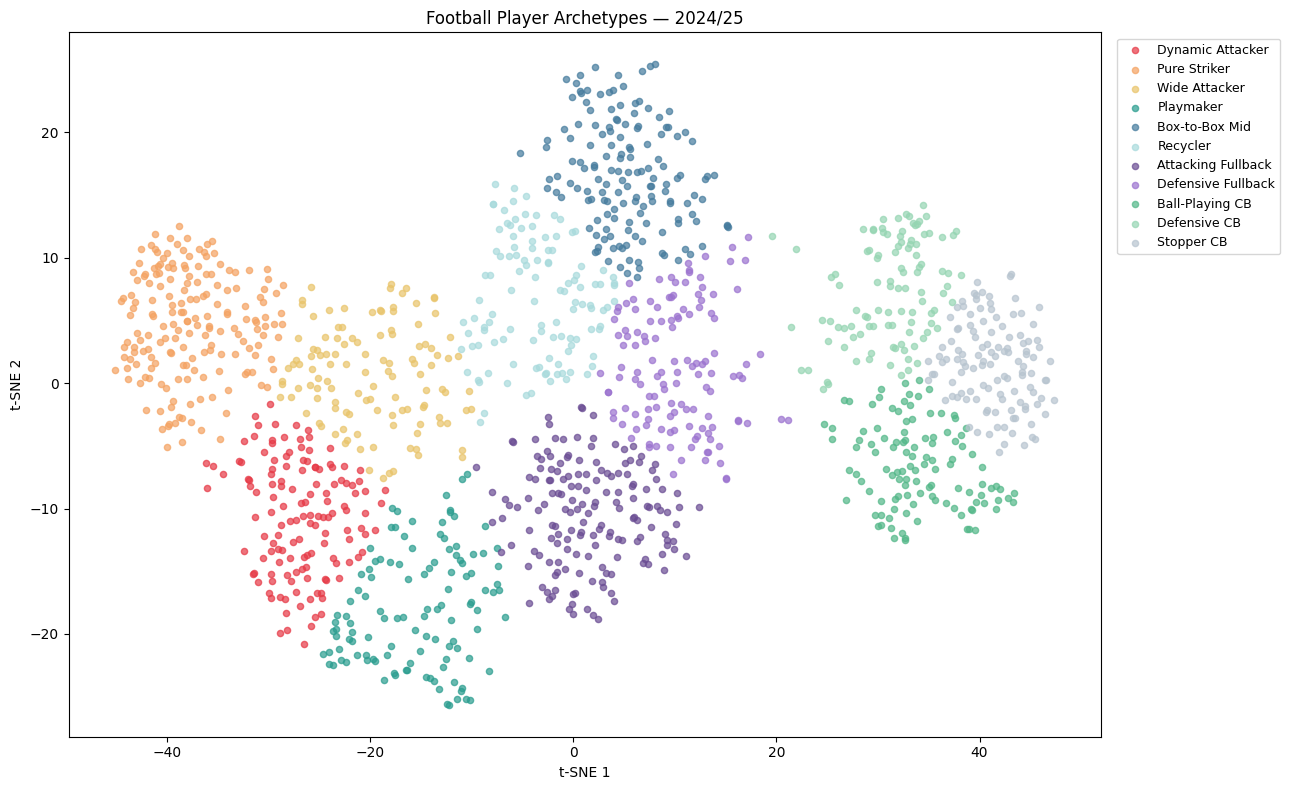

In [38]:
plt.figure(figsize=(13, 8))
for archetype, color in colors.items():
    mask = df_outfield['archetype'] == archetype
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=archetype, alpha=0.7, s=20)

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.title('Football Player Archetypes — 2024/25')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [39]:
def find_player(name):
    result = df_outfield[df_outfield['Player'].str.contains(name, case=False, na=False)]
    if result.empty:
        print(f"No player found matching '{name}'")
        return
    cols = ['Player', 'Pos', 'Squad', 'Comp', 'Min', 'archetype']
    print(result[cols].to_string(index=False))


find_player('Rodri')
find_player('Salah')
find_player('Bellingham')
find_player('Alexander-Arnold')

           Player Pos           Squad               Comp  Min      archetype
Rodrigo Bentancur  MF       Tottenham eng Premier League 1645 Box-to-Box Mid
  Rodrigo De Paul  MF Atlético Madrid         es La Liga 2106      Playmaker
    Rodrigo Muniz  FW          Fulham eng Premier League  964   Pure Striker
       Player Pos     Squad               Comp  Min        archetype
Mohamed Salah  FW Liverpool eng Premier League 3371 Dynamic Attacker
         Player Pos       Squad       Comp  Min archetype
Jude Bellingham  MF Real Madrid es La Liga 2488 Playmaker
                Player Pos     Squad               Comp  Min archetype
Trent Alexander-Arnold  DF Liverpool eng Premier League 2365 Playmaker


In [42]:
df_outfield = df_outfield.reset_index(drop=True)

highlight_players = [
    'Mohamed Salah', 'Kylian Mbappé', 'Erling Haaland',
    'Jude Bellingham', 'Pedri', 'Virgil van Dijk',
    'Trent Alexander-Arnold', 'Rodri', 'Vinícius Júnior',
    'Cole Palmer', 'Bruno Fernandes', 'Lamine Yamal'
]

highlight_df = df_outfield[df_outfield['Player'].isin(highlight_players)].copy()
highlight_df['tsne_x'] = X_tsne[highlight_df.index, 0]
highlight_df['tsne_y'] = X_tsne[highlight_df.index, 1]

print(highlight_df[['Player', 'archetype', 'tsne_x', 'tsne_y']])

                      Player         archetype     tsne_x     tsne_y
39    Trent Alexander-Arnold         Playmaker -11.850692 -20.580456
140          Jude Bellingham         Playmaker -17.919569 -20.979563
433          Bruno Fernandes         Playmaker -19.479822 -22.188818
551           Erling Haaland      Pure Striker -43.893715   3.283151
864            Kylian Mbappé      Pure Striker -39.967255  -5.082762
1023             Cole Palmer  Dynamic Attacker -24.779484 -18.444771
1039                   Pedri         Playmaker -13.239715 -24.358803
1162           Mohamed Salah  Dynamic Attacker -30.490339 -13.910553
1351         Virgil van Dijk   Ball-Playing CB  32.903946  -8.943838
1415            Lamine Yamal         Playmaker -24.650642 -21.615335


In [46]:
find_player('Rodri')
find_player('Vini')

           Player Pos           Squad               Comp  Min      archetype
Rodrigo Bentancur  MF       Tottenham eng Premier League 1645 Box-to-Box Mid
  Rodrigo De Paul  MF Atlético Madrid         es La Liga 2106      Playmaker
    Rodrigo Muniz  FW          Fulham eng Premier League  964   Pure Striker
         Player Pos       Squad       Comp  Min        archetype
Vinicius Júnior  FW Real Madrid es La Liga 2253 Dynamic Attacker


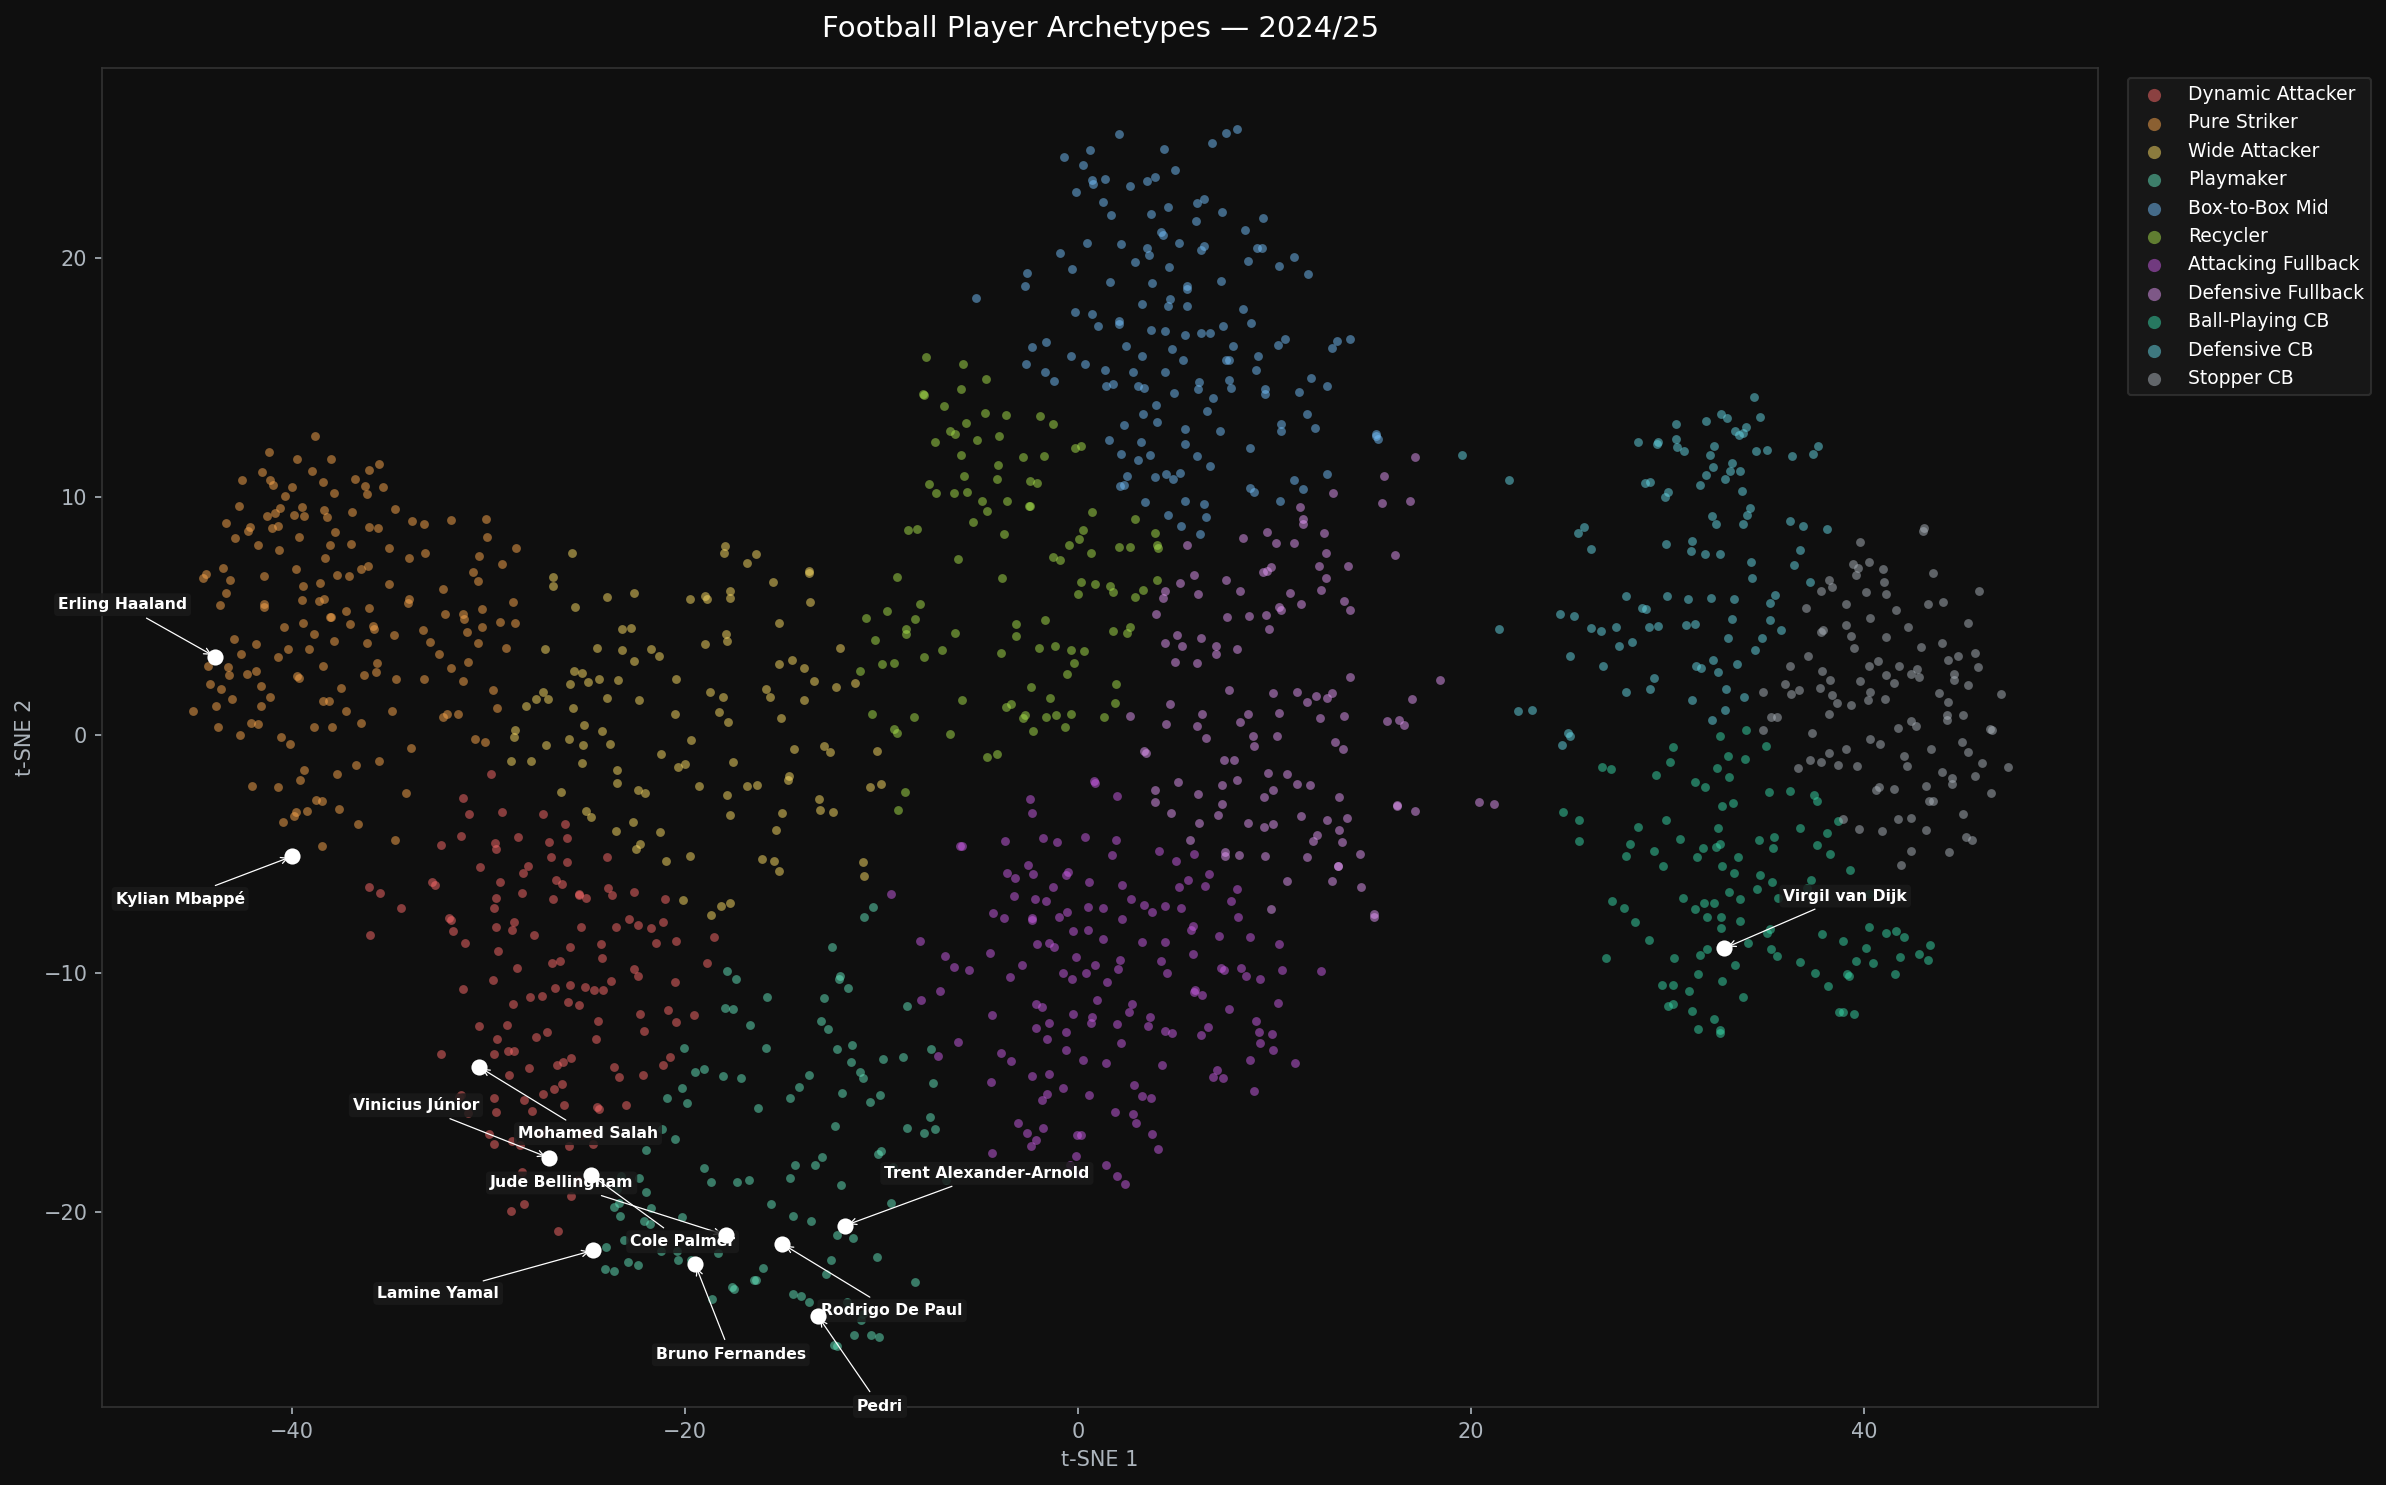

In [49]:
fig, ax = plt.subplots(figsize=(16, 10), dpi=150)
ax.set_facecolor('#0f0f0f')
fig.patch.set_facecolor('#0f0f0f')

# Base scatter
for archetype, color in colors_dark.items():
    mask = df_outfield['archetype'] == archetype
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=archetype,
               alpha=0.5, s=18, linewidths=0)

# Highlighted dots
ax.scatter(all_highlights['tsne_x'], all_highlights['tsne_y'],
           c='white', s=60, zorder=5, linewidths=0)

# Manual offsets to avoid label overlaps - (x_offset, y_offset) per player
offsets = {
    'Erling Haaland':         (-8, 2),
    'Kylian Mbappé':          (-9, -2),
    'Mohamed Salah':          (2, -3),
    'Vinicius Júnior':        (-10, 2),
    'Cole Palmer':            (2, -3),
    'Lamine Yamal':           (-11, -2),
    'Bruno Fernandes':        (-2, -4),
    'Jude Bellingham':        (-12, 2),
    'Trent Alexander-Arnold': (2, 2),
    'Rodrigo De Paul':        (2, -3),
    'Pedri':                  (2, -4),
    'Virgil van Dijk':        (3, 2),
}

for _, row in all_highlights.iterrows():
    ox, oy = offsets.get(row['Player'], (2, 2))
    ax.annotate(
        row['Player'],
        xy=(row['tsne_x'], row['tsne_y']),
        xytext=(row['tsne_x'] + ox, row['tsne_y'] + oy),
        fontsize=7.5,
        fontweight='bold',
        color='white',
        arrowprops=dict(arrowstyle='->', color='white', lw=0.6),
        bbox=dict(boxstyle='round,pad=0.25', fc='#1a1a1a', alpha=0.85, ec='none')
    )

# Fix legend - explicitly set marker colors
legend = ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
                   facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')
for handle, color in zip(legend.legend_handles, colors_dark.values()):
    handle.set_color(color)
    handle.set_sizes([40])

ax.set_title('Football Player Archetypes — 2024/25',
             fontsize=14, color='white', pad=15)
ax.set_xlabel('t-SNE 1', color='#adb5bd')
ax.set_ylabel('t-SNE 2', color='#adb5bd')
ax.tick_params(colors='#adb5bd')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

plt.tight_layout()
plt.savefig('archetypes_2024_25.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

In [50]:
# Export final results
output = df_outfield[['Player', 'Pos', 'Squad', 'Comp', 'Age', 'Min', 'archetype']].copy()
output = output.sort_values('archetype')
output.to_csv('player_archetypes_2024_25.csv', index=False)

print(f"Exported {len(output)} players")
print("\nArchetype breakdown:")
print(output['archetype'].value_counts())

Exported 1450 players

Archetype breakdown:
archetype
Pure Striker          180
Attacking Fullback    164
Box-to-Box Mid        152
Dynamic Attacker      138
Defensive Fullback    130
Stopper CB            118
Wide Attacker         118
Playmaker             117
Ball-Playing CB       114
Recycler              114
Defensive CB          105
Name: count, dtype: int64
